-3173.17229395 14.0


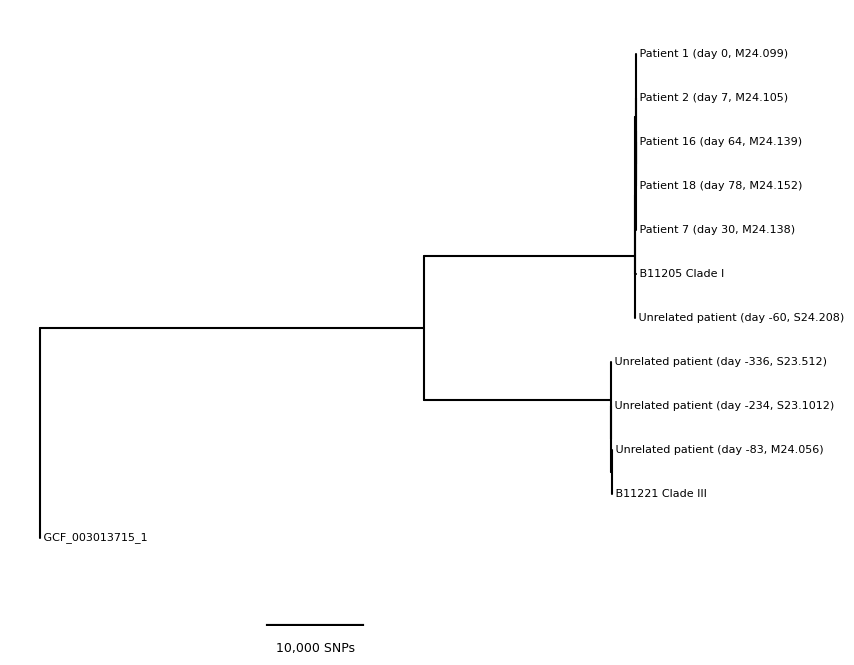

In [360]:
from Bio import Phylo
from io import StringIO
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.size"] = 8

nwk = "((M24_099_concat:0.000000, (B11205_Clade_I:32.637500, (S24_208:58.354167, (reference:40901.044643, (S23_512:0.000000, (S23_1012_concat:0.000000, (M24_056:71.900000, B11221_Clade_III:13.100000):29.500000):2.750000):19928.830357):22420.208333):70.737500):62.140625):3.979492, (M24_105:1.176758, (M24_152:2.733073, M24_139:3.266927):1.823242):0.245117, M24_138:2.754883);"

tree = Phylo.read(StringIO(nwk), "newick")
tree.root_with_outgroup("reference")

names = {
    "M24_105": "Patient 2 (day 7, M24.105)",
    "M24_152": "Patient 18 (day 78, M24.152)",
    "M24_139": "Patient 16 (day 64, M24.139)",
    "M24_138": "Patient 7 (day 30, M24.138)",
    "M24_099_concat": "Patient 1 (day 0, M24.099)",
    "S24_208": "Unrelated patient (day -60, S24.208)",
    "S23_512": "Unrelated patient (day -336, S23.512)",
    "S23_1012_concat": "Unrelated patient (day -234, S23.1012)",

    "M24_056": "Unrelated patient (day -83, M24.056)",
    "B11221_Clade_III": "B11221 Clade III",
    "B11205_Clade_I": "B11205 Clade I",
    "reference": "GCF_003013715_1"
}

for clade in tree.find_elements():
    if clade.name in names:
        clade.name = names[clade.name]

def contains_leaf(clade, name):
    return any(t.name == name for t in clade.get_terminals())

PRIORITY = {
    "Patient 1 (day 0, M24.099)":   0,
    "Patient 2 (day 7, M24.105)":   1,
    "Patient 7 (day 30, M24.138)":  2,
    "Patient 16 (day 64, M24.139)": 3,
    "Patient 18 (day 78, M24.152)": 4,
}

def clade_priority(clade):
    """Best (lowest) priority found among all leaves in this clade."""
    return min(
        (PRIORITY[t.name] for t in clade.get_terminals() if t.name in PRIORITY),
        default=99
    )

for internal in tree.get_nonterminals():
 
    if not any(t.name in PRIORITY for t in internal.get_terminals()):
        continue
    internal.clades.sort(key=clade_priority)

ref = next(tree.find_elements(name="GCF_003013715_1"))

fig, ax = plt.subplots(figsize=(10, 8))
Phylo.draw(tree, axes=ax, label_func=lambda x: "" if x.name == "" else x.name, do_show=False)

non_ref_terminals = [c for c in tree.get_terminals() if c.name != "reference"]
non_ref_root = tree.common_ancestor(non_ref_terminals)
clade_start = tree.distance(non_ref_root)

phantom = Clade(name="", branch_length=0)
non_ref_root.clades.insert(1, phantom)

xmax = ax.get_xlim()[1]
ax.set_ylim(14, 0)


ax.axis("off")

scale_length = 10000  
xmin = ax.get_xlim()[0]
xinc = (ax.get_xlim()[1] - xmin) / 3
ymin = ax.get_ylim()[0]
print(xmin, ymin)

ax.plot([xmin + xinc, xmin + xinc + scale_length], [ymin, ymin], 'k-', linewidth=3)
ax.text(xmin + xinc + scale_length / 2, ymin + 0.6, f"{scale_length:,} SNPs",
        ha="center", fontsize=9)

fig.savefig("tree.svg", format="svg")

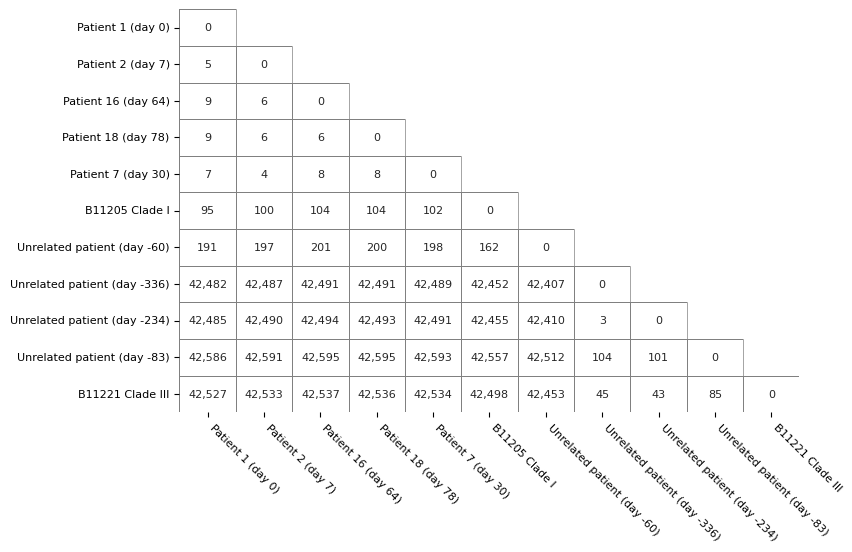

In [367]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Phylo

tree2 = Phylo.read(StringIO(nwk), "newick")

names2 = {
    "M24_105": "Patient 2 (day 7)",
    "M24_152": "Patient 18 (day 78)",
    "M24_139": "Patient 16 (day 64)",
    "M24_138": "Patient 7 (day 30)",
    "M24_099_concat": "Patient 1 (day 0)",
    "S24_208": "Unrelated patient (day -60)",
    "S23_512": "Unrelated patient (day -336)",
    "S23_1012_concat": "Unrelated patient (day -234)",

    "M24_056": "Unrelated patient (day -83)",
    "B11221_Clade_III": "B11221 Clade III",
    "B11205_Clade_I": "B11205 Clade I",
    "reference": "GCF_003013715_1"
}

for clade in tree2.find_elements():
    if clade.name in names2:
        clade.name = names2[clade.name]


tips = [t.name for t in tree2.get_terminals() if (t.name and t.name != "GCF_003013715_1")]

import re

ORDER = [
    "Patient 1 (day 0)",
    "Patient 2 (day 7)",
    "Patient 16 (day 64)",
    "Patient 18 (day 78)",
    "Patient 7 (day 30)",
    "B11205 Clade I",
    "Unrelated patient (day -60)",
    "Unrelated patient (day -336)",
    "Unrelated patient (day -234)",
    "Unrelated patient (day -83)",
    "B11221 Clade III",
]

tips = sorted(tips, key=lambda t: ORDER.index(t) if t in ORDER else len(ORDER))
n = len(tips)
mat = np.zeros((n, n))
for i, t1 in enumerate(tips):
    if t1:
        for j, t2 in enumerate(tips):
            if t2:
                mat[i, j] = tree2.distance(t1, t2)

mask = np.triu(np.ones_like(mat, dtype=bool), k=1)

def replace_second_space(s):
    if not "(" in s: return s
    first = s.index(' ')                        
    second = s.index(' ', first + 1)            
    return s[:second] + '\n' + s[second + 1:]

tips_display = [t for t in tips]
fig, ax = plt.subplots(figsize=(8, 7))
mat_formatted = np.vectorize(lambda x: f"{x:,.0f}")(mat)

sns.heatmap(
    mat,
    mask=mask,
    xticklabels=tips_display,
    yticklabels=tips_display,
    annot=mat_formatted,  
    fmt="",               
    cmap=["white"],
    cbar=False,
    linewidths=0.5,
    linecolor="gray",
    ax=ax,
)

ax.set_aspect(0.65)

for i in range(n):
    for j in range(n):
        if mask[i, j]:
            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1,
                fill=True, facecolor="white",
                linewidth=0, zorder=3
            ))

for i in range(n):
    ax.plot([i + 1, i + 1], [i, i + 1], color="gray", linewidth=0.5, zorder=4)


plt.xticks(rotation=-45, ha="left")
plt.yticks(ha="right", multialignment = "center")
fig.savefig("distance_matrix.svg", format="svg")

100
100
0.0 12.0


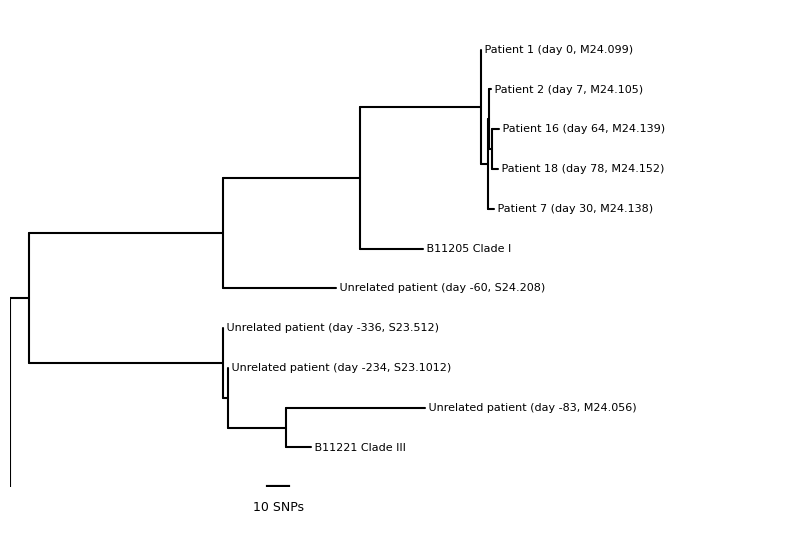

In [345]:
ref.branch_length = 0

non_ref_root = [c for c in tree.root.clades if c.name != "GCF_003013715_1"][0]
for child in non_ref_root.clades:
    print(child.branch_length)

for child in non_ref_root.clades:
    child.branch_length = 100  # tweak to taste

non_ref_root.branch_length = 10

fig,ax = plt.subplots(figsize=(10, 6.2))
Phylo.draw(tree, axes=ax, label_func=lambda x: "" if (x.name == "" or x.name == "GCF_003013715_1") else x.name, do_show=False)

non_ref_terminals = [c for c in tree.get_terminals() if c.name != "GCF_003013715_1"]
non_ref_root = tree.common_ancestor(non_ref_terminals)
clade_start = tree.distance(non_ref_root)

xmax = ax.get_xlim()[1]
ax.set_xlim(0, 400)
ax.set_ylim(12, 0)


ax.axis("off")

scale_length = 10  # SNPs — adjust to taste
xmin = ax.get_xlim()[0]
xinc = (ax.get_xlim()[1] - xmin) / 3
ymin = ax.get_ylim()[0]
print(xmin, ymin)

ax.plot([xmin + xinc, xmin + xinc + scale_length], [ymin, ymin], 'k-', linewidth=3)
ax.text(xmin + xinc + scale_length / 2, ymin + 0.6, f"{scale_length} SNPs",
        ha="center", fontsize=9)

fig.savefig("tree_zoomed.svg", format="svg")